# Layer-wise Probing Experiment:

This notebook implements a probing experiment to test whether the `aya-expanse-8b` language model
encodes semantic roles (Agent vs Patient) in its hidden representations.

**Approach:**
1. Extract hidden states for target nouns in sentences with known Agent/Patient labels.
2. Train a linear classifier (logistic regression) on those hidden states.
3. Evaluate with cross-validation and on a held-out test set.

**Design choices to avoid trivial heuristics:**
- Same nouns appear as both Agent and Patient across examples.
- Both active constructions (Agent-first) and passive constructions (Patient-first) are included.
- Word position or grammatical role (subject, object) is therefore not a reliable cue for semantic role.

**Requirements:** GPU needed: run with Google Colab kernel (T4).

## Quick check if I'm connected to the colab GPU kernel (T4)

In [ ]:
import os
import sys

print("python_executable:", sys.executable)
print("google.colab in modules:", "google.colab" in sys.modules)
print("COLAB_GPU env:", os.environ.get("COLAB_GPU"))

try:
    page_size = os.sysconf("SC_PAGE_SIZE")
    phys_pages = os.sysconf("SC_PHYS_PAGES")
    total_gb = (page_size * phys_pages) / (1024 ** 3)
    print(f"system_ram_gb: {total_gb:.2f}")
except Exception as e:
    print("ram_check_error:", str(e))

try:
    import torch
    print("torch_version:", torch.__version__)
    print("cuda_available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu_name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch_check_error:", str(e))

## 1. Install Dependencies and get Access to Aya model

In [ ]:
# Install required packages (uncomment if running in a fresh Colab environment)
#%pip install transformers torch scikit-learn accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.4 MB/s eta 0:00:00:00:0100:01


In [ ]:
# Hugging Face authentication for gated Aya model access
# Run this once per new kernel session.
from getpass import getpass
from huggingface_hub import login
from transformers import AutoConfig

token = getpass("Paste your Hugging Face read token, then press Enter: ").strip()
if not token:
    raise ValueError("No token entered. Please rerun this cell and paste your token.")
if not token.startswith("hf_"):
    raise ValueError("Token format looks invalid. It should usually start with 'hf_'.")

login(token=token, add_to_git_credential=False)

# Quick access check for the gated model
cfg = AutoConfig.from_pretrained("CohereForAI/aya-expanse-8b")
print("Hugging Face auth OK. Model type:", cfg.model_type)

config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

Hugging Face auth OK. Model type: cohere


## 2. Imports

In [5]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from typing import List, Tuple, Dict, Optional

## 3. Model Loading

In [ ]:
def load_model_and_tokenizer(
    model_name: str = "CohereForAI/aya-expanse-8b",
    device: Optional[str] = None,
) -> Tuple[AutoModelForCausalLM, AutoTokenizer, str]:
    
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Loading tokenizer for '{model_name}'...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    print(f"Loading model on device: {device}")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        output_hidden_states=True,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()

    print("Model loaded successfully.")
    return model, tokenizer, device

## 4. Hidden State Extraction

In [ ]:
def find_token_positions(
    tokenizer: AutoTokenizer,
    input_ids: torch.Tensor,
    target_word: str,
) -> List[int]:
   
    tokens = tokenizer.convert_ids_to_tokens(input_ids.tolist())
    target_lower = target_word.lower()

    clean_tokens = [
        t.lstrip("▁Ġ#").lower() if t is not None else "" for t in tokens
    ]

    positions = []
    for i, ct in enumerate(clean_tokens):
        if ct == target_lower:
            positions.append(i)

    if not positions:
        for i in range(len(tokens)):
            merged = ""
            span = []
            for j in range(i, len(tokens)):
                merged += clean_tokens[j]
                span.append(j)
                if merged == target_lower:
                    positions = span
                    break
                if len(merged) >= len(target_lower):
                    break
            if positions:
                break

    return positions


def mark_target_in_sentence(sentence: str, target_word: str) -> str:

    lower_sentence = sentence.lower()
    lower_target = target_word.lower()
    start = lower_sentence.find(lower_target)
    if start == -1:
        raise ValueError(f"Target word '{target_word}' not found in sentence: '{sentence}'")

    end = start + len(target_word)
    marked = sentence[:start] + f"<tgt> {sentence[start:end]} </tgt>" + sentence[end:]
    return marked


def extract_hidden_state(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    sentence: str,
    target_word: str,
    layer: int = -1,
    device: str = "cpu",
) -> np.ndarray:

    marked_sentence = mark_target_in_sentence(sentence, target_word)
    inputs = tokenizer(marked_sentence, return_tensors="pt")

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states
    layer_states = hidden_states[layer]
    representation = layer_states[0, -1, :].float().cpu().numpy()

    return representation

## 5. Dataset Construction

Each example is a tuple: `(sentence, target_word, label)` where label is `"Agent"` or `"Patient"`.

In [ ]:
def create_dataset() -> List[Tuple[str, str, str]]:

    examples = [
        # ---- dog / cat ------------------------------------------------	
        ("The dog chased the cat.", "dog", "Agent"),
        ("The dog chased the cat.", "cat", "Patient"),
        ("The cat was chased by the dog.", "cat", "Patient"),
        ("The cat was chased by the dog.", "dog", "Agent"),
        ("The cat scratched the dog.", "cat", "Agent"),
        ("The cat scratched the dog.", "dog", "Patient"),
        ("The dog was scratched by the cat.", "dog", "Patient"),
        ("The dog was scratched by the cat.", "cat", "Agent"),
        # ---- man / woman ---------------------------------------------
        ("The man saw the woman.", "man", "Agent"),
        ("The man saw the woman.", "woman", "Patient"),
        ("The woman was seen by the man.", "woman", "Patient"),
        ("The woman was seen by the man.", "man", "Agent"),
        ("The woman helped the man.", "woman", "Agent"),
        ("The woman helped the man.", "man", "Patient"),
        ("The man was helped by the woman.", "man", "Patient"),
        ("The man was helped by the woman.", "woman", "Agent"),
        # ---- child / teacher -----------------------------------------
        ("The child found the teacher.", "child", "Agent"),
        ("The child found the teacher.", "teacher", "Patient"),
        ("The teacher was found by the child.", "teacher", "Patient"),
        ("The teacher was found by the child.", "child", "Agent"),
        ("The teacher scolded the child.", "teacher", "Agent"),
        ("The teacher scolded the child.", "child", "Patient"),
        ("The child was scolded by the teacher.", "child", "Patient"),
        ("The child was scolded by the teacher.", "teacher", "Agent"),
        # ---- bird / fox -----------------------------------------------
        ("The bird spotted the fox.", "bird", "Agent"),
        ("The bird spotted the fox.", "fox", "Patient"),
        ("The fox was spotted by the bird.", "fox", "Patient"),
        ("The fox was spotted by the bird.", "bird", "Agent"),
        ("The fox chased the bird.", "fox", "Agent"),
        ("The fox chased the bird.", "bird", "Patient"),
        ("The bird was chased by the fox.", "bird", "Patient"),
        ("The bird was chased by the fox.", "fox", "Agent"),
        # ---- student / professor -------------------------------------
        ("The student greeted the professor.", "student", "Agent"),
        ("The student greeted the professor.", "professor", "Patient"),
        ("The professor was greeted by the student.", "professor", "Patient"),
        ("The professor was greeted by the student.", "student", "Agent"),
        ("The professor praised the student.", "professor", "Agent"),
        ("The professor praised the student.", "student", "Patient"),
        ("The student was praised by the professor.", "student", "Patient"),
        ("The student was praised by the professor.", "professor", "Agent"),
        # ---- lion / zebra --------------------------------------------
        ("The lion caught the zebra.", "lion", "Agent"),
        ("The lion caught the zebra.", "zebra", "Patient"),
        ("The zebra was caught by the lion.", "zebra", "Patient"),
        ("The zebra was caught by the lion.", "lion", "Agent"),
        ("The zebra kicked the lion.", "zebra", "Agent"),
        ("The zebra kicked the lion.", "lion", "Patient"),
        ("The lion was kicked by the zebra.", "lion", "Patient"),
        ("The lion was kicked by the zebra.", "zebra", "Agent"),
        # ---- doctor / patient (role noun used intentionally) ---------
        ("The doctor examined the nurse.", "doctor", "Agent"),
        ("The doctor examined the nurse.", "nurse", "Patient"),
        ("The nurse was examined by the doctor.", "nurse", "Patient"),
        ("The nurse was examined by the doctor.", "doctor", "Agent"),
        ("The nurse assisted the doctor.", "nurse", "Agent"),
        ("The nurse assisted the doctor.", "doctor", "Patient"),
        ("The doctor was assisted by the nurse.", "doctor", "Patient"),
        ("The doctor was assisted by the nurse.", "nurse", "Agent"),
        # ---- cat / mouse ---------------------------------------------
        ("The cat caught the mouse.", "cat", "Agent"),
        ("The cat caught the mouse.", "mouse", "Patient"),
        ("The mouse was caught by the cat.", "mouse", "Patient"),
        ("The mouse was caught by the cat.", "cat", "Agent"),
        ("The mouse bit the cat.", "mouse", "Agent"),
        ("The mouse bit the cat.", "cat", "Patient"),
        ("The cat was bitten by the mouse.", "cat", "Patient"),
        ("The cat was bitten by the mouse.", "mouse", "Agent"),
        # ---- boy / girl -----------------------------------------------
        ("The boy pushed the girl.", "boy", "Agent"),
        ("The boy pushed the girl.", "girl", "Patient"),
        ("The girl was pushed by the boy.", "girl", "Patient"),
        ("The girl was pushed by the boy.", "boy", "Agent"),
        ("The girl hugged the boy.", "girl", "Agent"),
        ("The girl hugged the boy.", "boy", "Patient"),
        ("The boy was hugged by the girl.", "boy", "Patient"),
        ("The boy was hugged by the girl.", "girl", "Agent"),
        # ---- wolf / deer ---------------------------------------------
        ("The wolf frightened the deer.", "wolf", "Agent"),
        ("The wolf frightened the deer.", "deer", "Patient"),
        ("The deer was frightened by the wolf.", "deer", "Patient"),
        ("The deer was frightened by the wolf.", "wolf", "Agent"),
        ("The deer kicked the wolf.", "deer", "Agent"),
        ("The deer kicked the wolf.", "wolf", "Patient"),
        ("The wolf was kicked by the deer.", "wolf", "Patient"),
        ("The wolf was kicked by the deer.", "deer", "Agent"),
        # ---- chef / guest --------------------------------------------
        ("The chef served the guest.", "chef", "Agent"),
        ("The chef served the guest.", "guest", "Patient"),
        ("The guest was served by the chef.", "guest", "Patient"),
        ("The guest was served by the chef.", "chef", "Agent"),
        ("The guest praised the chef.", "guest", "Agent"),
        ("The guest praised the chef.", "chef", "Patient"),
        ("The chef was praised by the guest.", "chef", "Patient"),
        ("The chef was praised by the guest.", "guest", "Agent"),
        # ---- officer / suspect ---------------------------------------
        ("The officer arrested the suspect.", "officer", "Agent"),
        ("The officer arrested the suspect.", "suspect", "Patient"),
        ("The suspect was arrested by the officer.", "suspect", "Patient"),
        ("The suspect was arrested by the officer.", "officer", "Agent"),
        ("The suspect challenged the officer.", "suspect", "Agent"),
        ("The suspect challenged the officer.", "officer", "Patient"),
        ("The officer was challenged by the suspect.", "officer", "Patient"),
        ("The officer was challenged by the suspect.", "suspect", "Agent"),
        # ---- horse / rider -------------------------------------------
        ("The horse threw the rider.", "horse", "Agent"),
        ("The horse threw the rider.", "rider", "Patient"),
        ("The rider was thrown by the horse.", "rider", "Patient"),
        ("The rider was thrown by the horse.", "horse", "Agent"),
        ("The rider guided the horse.", "rider", "Agent"),
        ("The rider guided the horse.", "horse", "Patient"),
        ("The horse was guided by the rider.", "horse", "Patient"),
        ("The horse was guided by the rider.", "rider", "Agent"),
        # ---- scientist / assistant -----------------------------------
        ("The scientist observed the assistant.", "scientist", "Agent"),
        ("The scientist observed the assistant.", "assistant", "Patient"),
        ("The assistant was observed by the scientist.", "assistant", "Patient"),
        ("The assistant was observed by the scientist.", "scientist", "Agent"),
        ("The assistant supported the scientist.", "assistant", "Agent"),
        ("The assistant supported the scientist.", "scientist", "Patient"),
        ("The scientist was supported by the assistant.", "scientist", "Patient"),
        ("The scientist was supported by the assistant.", "assistant", "Agent"),
        # ---- eagle / rabbit ------------------------------------------
        ("The eagle grabbed the rabbit.", "eagle", "Agent"),
        ("The eagle grabbed the rabbit.", "rabbit", "Patient"),
        ("The rabbit was grabbed by the eagle.", "rabbit", "Patient"),
        ("The rabbit was grabbed by the eagle.", "eagle", "Agent"),
        ("The rabbit evaded the eagle.", "rabbit", "Agent"),
        ("The rabbit evaded the eagle.", "eagle", "Patient"),
        ("The eagle was evaded by the rabbit.", "eagle", "Patient"),
        ("The eagle was evaded by the rabbit.", "rabbit", "Agent"),
        # ---- pilot / passenger ---------------------------------------
        ("The pilot warned the passenger.", "pilot", "Agent"),
        ("The pilot warned the passenger.", "passenger", "Patient"),
        ("The passenger was warned by the pilot.", "passenger", "Patient"),
        ("The passenger was warned by the pilot.", "pilot", "Agent"),
        ("The passenger thanked the pilot.", "passenger", "Agent"),
        ("The passenger thanked the pilot.", "pilot", "Patient"),
        ("The pilot was thanked by the passenger.", "pilot", "Patient"),
        ("The pilot was thanked by the passenger.", "passenger", "Agent"),
        # ---- shark / diver -------------------------------------------
        ("The shark frightened the diver.", "shark", "Agent"),
        ("The shark frightened the diver.", "diver", "Patient"),
        ("The diver was frightened by the shark.", "diver", "Patient"),
        ("The diver was frightened by the shark.", "shark", "Agent"),
        ("The diver observed the shark.", "diver", "Agent"),
        ("The diver observed the shark.", "shark", "Patient"),
        ("The shark was observed by the diver.", "shark", "Patient"),
        ("The shark was observed by the diver.", "diver", "Agent"),
        # ---- king / knight -------------------------------------------
        ("The king summoned the knight.", "king", "Agent"),
        ("The king summoned the knight.", "knight", "Patient"),
        ("The knight was summoned by the king.", "knight", "Patient"),
        ("The knight was summoned by the king.", "king", "Agent"),
        ("The knight protected the king.", "knight", "Agent"),
        ("The knight protected the king.", "king", "Patient"),
        ("The king was protected by the knight.", "king", "Patient"),
        ("The king was protected by the knight.", "knight", "Agent"),
        # ---- journalist / editor ------------------------------------
        ("The journalist interviewed the editor.", "journalist", "Agent"),
        ("The journalist interviewed the editor.", "editor", "Patient"),
        ("The editor was interviewed by the journalist.", "editor", "Patient"),
        ("The editor was interviewed by the journalist.", "journalist", "Agent"),
        ("The editor reviewed the journalist.", "editor", "Agent"),
        ("The editor reviewed the journalist.", "journalist", "Patient"),
        ("The journalist was reviewed by the editor.", "journalist", "Patient"),
        ("The journalist was reviewed by the editor.", "editor", "Agent"),
    ]

    assert len(examples) == 152, f"Expected 152 examples, got {len(examples)}"
    return examples


def get_dataset_statistics(dataset: List[Tuple[str, str, str]]) -> None:
    
    labels = [label for _, _, label in dataset]
    agents = labels.count("Agent")
    patients = labels.count("Patient")
    print(f"Total examples : {len(dataset)}")
    print(f"  Agent  labels: {agents}")
    print(f"  Patient labels: {patients}")

    # Count active vs passive sentences
    active_count = sum(1 for s, _, _ in dataset if " was " not in s and " were " not in s)
    passive_count = len(dataset) - active_count
    print(f"  Active  sentences: {active_count}")
    print(f"  Passive sentences: {passive_count}")

    # Check that all nouns appear as both Agent and Patient
    noun_roles: Dict[str, set] = {}
    for _, noun, label in dataset:
        noun_roles.setdefault(noun, set()).add(label)
    both_roles = {n for n, r in noun_roles.items() if len(r) == 2}
    print(f"  Nouns with both Agent & Patient labels: {len(both_roles)} / {len(noun_roles)}")

## 6. Feature Extraction Pipeline

In [ ]:
def build_feature_matrix(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    dataset: List[Tuple[str, str, str]],
    layer: int = -1,
    device: str = "cpu",
) -> Tuple[np.ndarray, np.ndarray]:

    X, y = [], []
    skipped = []

    for i, (sentence, target_word, label) in enumerate(dataset):
        try:
            vec = extract_hidden_state(
                model, tokenizer, sentence, target_word,
                layer=layer, device=device
            )
            X.append(vec)
            y.append(label)
        except ValueError as e:
            print(f"[WARNING] Skipping example {i}: {e}")
            skipped.append(i)

        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(dataset)} examples...")

    if skipped:
        print(f"[WARNING] {len(skipped)} examples were skipped due to tokenization issues.")

    return np.array(X), np.array(y)

## 7. Classifier Training and Evaluation

In [ ]:
def train_and_evaluate(
    X: np.ndarray,
    y: np.ndarray,
    n_train: int = 125,
    cv_folds: int = 5,
    random_state: int = 42,
    c_value: float = 3.0,
) -> LogisticRegression:

    n_test = len(X) - n_train
    print(f"Dataset size: {len(X)} total ({n_train} train, {n_test} test)")

    # Encode labels to integers for compatibility
    le = LabelEncoder()
    y_enc = le.fit_transform(y)  # Agent=0, Patient=1
    print(f"Label encoding: {list(zip(le.classes_, range(len(le.classes_))))}")

    # Split into train / test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc,
        train_size=n_train,
        test_size=n_test,
        random_state=random_state,
        stratify=y_enc,
    )
    print(f"Train class distribution: { {le.classes_[i]: (y_train == i).sum() for i in range(len(le.classes_))} }")
    print(f"Test  class distribution: { {le.classes_[i]: (y_test  == i).sum() for i in range(len(le.classes_))} }")

    # Define the probe classifier
    clf = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        solver="lbfgs",
        C=c_value,
    )

    print(f"\nRunning {cv_folds}-fold cross-validation on training set...")
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv_folds, scoring="accuracy")
    print(f"Cross-validation accuracy (per fold): {np.round(cv_scores, 4)}")
    print(f"Cross-validation accuracy (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train final classifier on full training set
    clf.fit(X_train, y_train)

    # Evaluate on held-out test set                                      #
    test_accuracy = clf.score(X_test, y_test)
    print(f"\nTest accuracy: {test_accuracy:.4f}")

    return clf

## 8. Layer-wise Probing

Run the probe at every transformer layer to see which layer best encodes semantic roles.

In [ ]:
def extract_all_layers(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    dataset: List[Tuple[str, str, str]],
    device: str,
) -> Tuple[Dict[int, np.ndarray], np.ndarray, np.ndarray]:
 
    n_layers = model.config.num_hidden_layers
    layer_vecs = {i: [] for i in range(n_layers + 1)}
    y = []
    kept_indices = []
    skipped = []

    for i, (sentence, target_word, label) in enumerate(dataset):
        try:
            marked_sentence = mark_target_in_sentence(sentence, target_word)
            inputs = tokenizer(marked_sentence, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = model(**inputs)

            for layer_idx in range(n_layers + 1):
                vec = outputs.hidden_states[layer_idx][0, -1, :].float().cpu().numpy()
                layer_vecs[layer_idx].append(vec)

            y.append(label)
            kept_indices.append(i)
        except ValueError as e:
            print(f"[WARNING] Skipping example {i}: {e}")
            skipped.append(i)

        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(dataset)} examples...")

    if skipped:
        print(f"[WARNING] {len(skipped)} examples were skipped.")

    layer_X = {k: np.array(v) for k, v in layer_vecs.items()}
    return layer_X, np.array(y), np.array(kept_indices)


def run_layerwise_probing(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    dataset: List[Tuple[str, str, str]],
    device: str,
    n_train: int = 125,
    cv_folds: int = 5,
    random_state: int = 42,
    c_value: float = 3.0,
) -> Tuple[Dict[int, Dict[str, object]], Dict[int, np.ndarray], np.ndarray, Dict[str, object], Dict[int, List[Dict[str, object]]]]:
 
    n_layers = model.config.num_hidden_layers
    print(f"Model has {n_layers} transformer layers (+ embedding layer).")

    print("\nExtracting hidden states for ALL layers in a single pass...")
    layer_X, y, kept_indices = extract_all_layers(model, tokenizer, dataset, device)
    print(f"Extraction complete. Feature shape per layer: {layer_X[0].shape}")

    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    n_test = len(y_enc) - n_train

    all_idx = np.arange(len(y_enc))
    train_idx, test_idx = train_test_split(
        all_idx,
        train_size=n_train,
        test_size=n_test,
        random_state=random_state,
        stratify=y_enc,
    )

    split_info = {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "label_encoder": le,
        "kept_indices": kept_indices,
    }

    results = {}
    per_layer_predictions = {}
    for layer_idx in range(n_layers + 1):
        X = layer_X[layer_idx]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        clf = LogisticRegression(max_iter=1000, random_state=random_state, C=c_value)
        cv_scores = cross_val_score(clf, X_train, y_train, cv=cv_folds, scoring="accuracy")
        cv_mean = float(cv_scores.mean())
        cv_std = float(cv_scores.std())

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        test_acc = float((y_pred == y_test).mean())

        results[layer_idx] = {
            "cv_accuracy": cv_mean,
            "cv_std": cv_std,
            "cv_scores": cv_scores.tolist(),
            "test_accuracy": test_acc,
        }
        print(f"\nLayer {layer_idx:3d}: CV accuracy = {cv_mean:.4f} +/- {cv_std:.4f}, test accuracy = {test_acc:.4f}")

        rows = []
        for pos, ds_pos in enumerate(test_idx):
            original_idx = int(kept_indices[ds_pos])
            sentence, target_word, _ = dataset[original_idx]
            true_label = le.inverse_transform([y_test[pos]])[0]
            pred_label = le.inverse_transform([y_pred[pos]])[0]
            is_correct = bool(y_pred[pos] == y_test[pos])
            rows.append({
                "dataset_index": original_idx,
                "target_word": target_word,
                "sentence": sentence,
                "true_label": true_label,
                "pred_label": pred_label,
                "correct": is_correct,
            })
        per_layer_predictions[layer_idx] = rows

        incorrect_rows = [r for r in rows if not r["correct"]]
        correct_rows = [r for r in rows if r["correct"]]

        print(f"  Incorrect: {len(incorrect_rows)} / {len(rows)}")
        for i, r in enumerate(incorrect_rows, 1):
            print(
                f"    [I{i:02d}] idx={r['dataset_index']:3d} word='{r['target_word']}' "
                f"true={r['true_label']} pred={r['pred_label']} | {r['sentence']}"
            )

        print(f"  Correct:   {len(correct_rows)} / {len(rows)}")
        for i, r in enumerate(correct_rows, 1):
            print(
                f"    [C{i:02d}] idx={r['dataset_index']:3d} word='{r['target_word']}' "
                f"label={r['true_label']} | {r['sentence']}"
            )

    best_layer_cv = max(results, key=lambda k: results[k]["cv_accuracy"])
    best_layer_test = max(results, key=lambda k: results[k]["test_accuracy"])
    print(f"\nBest layer (CV):   {best_layer_cv} (accuracy = {results[best_layer_cv]['cv_accuracy']:.4f})")
    print(f"Best layer (test): {best_layer_test} (accuracy = {results[best_layer_test]['test_accuracy']:.4f})")
    return results, layer_X, y_enc, split_info, per_layer_predictions


# Run layer-wise probing
model, tokenizer, device = load_model_and_tokenizer()
dataset = create_dataset()
layer_results, layer_X, y_enc, split_info, per_layer_predictions = run_layerwise_probing(
    model,
    tokenizer,
    dataset,
    device,
    c_value=3.0,
    n_train=125,
    cv_folds=5,
    random_state=42,
)

Loading tokenizer for 'CohereForAI/aya-expanse-8b'...
Loading model on device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded successfully.
Model has 32 transformer layers (+ embedding layer).

Extracting hidden states for ALL layers in a single pass...
  Processed 25/152 examples...
  Processed 50/152 examples...
  Processed 75/152 examples...
  Processed 100/152 examples...
  Processed 125/152 examples...
  Processed 150/152 examples...
Extraction complete. Feature shape per layer: (152, 4096)

Layer   0: CV accuracy = 0.4000 +/- 0.0438, test accuracy = 0.4444
  Incorrect: 15 / 27
    [I01] idx=  1 word='cat' true=Patient pred=Agent | The dog chased the cat.
    [I02] idx=129 word='diver' true=Patient pred=Agent | The shark frightened the diver.
    [I03] idx=149 word='journalist' true=Patient pred=Agent | The editor reviewed the journalist.
    [I04] idx= 40 word='lion' true=Agent pred=Patient | The lion caught the zebra.
    [I05] idx= 57 word='mouse' true=Patient pred=Agent | The cat caught the mouse.
    [I06] idx=120 word='pilot' true=Agent pred=Patient | The pilot warned the passenger.
  

## Plotting

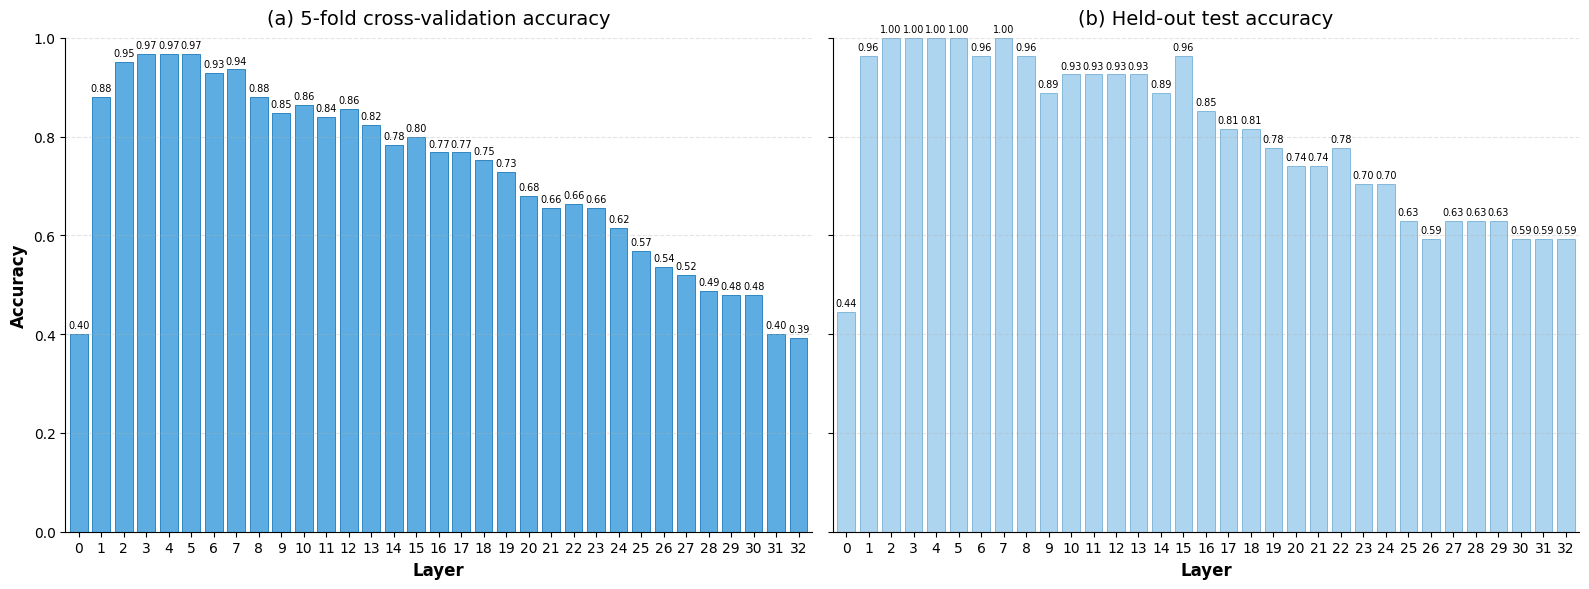

Left: mean 5-fold cross-validation accuracy by layer.
Right: held-out test accuracy by layer.


In [21]:
# Combined plot: cross-validation accuracy and test accuracy side by side
import matplotlib.pyplot as plt

if "layer_results" not in globals():
    raise RuntimeError(
        "Run the layer-wise probing cell first so layer_results is available for plotting."
    )

layers = sorted(layer_results.keys())
cv_accuracies = [layer_results[layer]["cv_accuracy"] for layer in layers]
test_accuracies = [layer_results[layer]["test_accuracy"] for layer in layers]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Left: cross-validation accuracy
axes[0].bar(
    layers,
    cv_accuracies,
    color="#5dade2",
    edgecolor="#2e86c1",
    linewidth=0.7,
    width=0.78,
)
for x_pos, value in zip(layers, cv_accuracies):
    axes[0].text(x_pos, value + 0.008, f"{value:.2f}", ha="center", va="bottom", fontsize=7)
axes[0].set_title("(a) 5-fold cross-validation accuracy", fontsize=14, pad=10)
axes[0].set_xlabel("Layer", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Accuracy", fontsize=12, fontweight="bold")
axes[0].set_xticks(layers)
axes[0].set_xlim(-0.6, max(layers) + 0.6)
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right: test accuracy
axes[1].bar(
    layers,
    test_accuracies,
    color="#5dade2",
    edgecolor="#2e86c1",
    linewidth=0.7,
    width=0.78,
    alpha=0.5,
)
for x_pos, value in zip(layers, test_accuracies):
    axes[1].text(x_pos, value + 0.008, f"{value:.2f}", ha="center", va="bottom", fontsize=7)
axes[1].set_title("(b) Held-out test accuracy", fontsize=14, pad=10)
axes[1].set_xlabel("Layer", fontsize=12, fontweight="bold")
axes[1].set_xticks(layers)
axes[1].set_xlim(-0.6, max(layers) + 0.6)
axes[1].grid(axis="y", linestyle="--", alpha=0.35)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Left: mean 5-fold cross-validation accuracy by layer.")
print("Right: held-out test accuracy by layer.")